# Exploration of California Wildfire Risk and Expected Loss to Housing
We will visualize California wildfire risk data using the example of San Francisco.
This provides a template for student analysis of the financial exposure of California homeowners and property owners to future wildfires for another city or county in California, following the approach in the forthcoming Buddhavarapu and Subin article from Terner Center.

The source data is [Open Climate Risk](https://carbonplan.org/research/climate-risk)  available directly from CarbonPlan: reference below.

While the underlying dataset consists of _parcel_-level estimates of risk to buildings 👨🏽‍💻, we will use the neighborhood-([census tract](https://en.wikipedia.org/wiki/Census_tract#United_States)) mean risk estimates here: download "stats.csv" from this [directory](https://source.coop/carbonplan/carbonplan-ocr/output/fire-risk/vector/production/v1.1.0/region-analysis/tracts) into the local `inputdata` folder.

Each row consists of a census tract [FIPS](https://www.census.gov/programs-surveys/geography/guidance/geo-identifiers.html) code and the average annual risk of loss (fraction per year) for buildings in the tract, projected under both historical and future climates.

Steps:

1. Load data, clean, and confirm the distribution is as expected.
2. Overlay with a standard census geographic shapefile for California tracts, excerpt for San Francisco, and visualize.
3. Overlay with owner-occupied homes and median home value from the most recently available American Community Survey (ACS) year.
4. Explore descriptive statistics useful for climate adaptation planning: total financial exposure and median-minimum required insurance premium for homeowners.

**Note**: It is recommended that you read the accompanying `vmt_explore.ipynb` template first, as this one will provide less verbose explanation of the coding steps inline, where concepts are already covered there.

### Reference
O. Chegwidden et al. (2026) “Making climate risk data open.” CarbonPlan. https://carbonplan.org/research/climate-risk-explainer

In [1]:
# Setup
import numpy as np # Core numerical and array operations
import pandas as pd # Data table and analysis operations
import matplotlib.pyplot as plt # Plotting; syntax and appearance similar to Matlab
import pathlib # file handling robust to switching between Mac, PC, and Linux platforms
import geopandas as gpd # GIS functionality added to pandas. We will use lightly here to make a map.

# For calling census API below
import census_helper

In [2]:
cwd = pathlib.Path().cwd() # Current working directory
cwd

PosixPath('/Users/zsubin/Code/usf-engy680-urban-energy-fall2026/hw2_templates')

In [3]:
inputdir = cwd / 'inputdata'
inputdir

PosixPath('/Users/zsubin/Code/usf-engy680-urban-energy-fall2026/hw2_templates/inputdata')

## Step 1: Load and clean data

In [4]:
datafile = inputdir / 'stats.csv'
# Downloaded from Carbon Plan link: https://source.coop/carbonplan/carbonplan-ocr/output/fire-risk/vector/production/v1.1.0/region-analysis/tracts
#data = pd.read_csv(datafile)
#data.head()

Oops! When we tried to read this as normal, we get:
`ParserError: Error tokenizing data. C error: Expected 1 fields in line 7, saw 3`.

This is why you should always inspect the data before you read it. Use the command-line "more" or "head" utility, VSCode, or a generic text editor, though-- if you double click on a large csv like this it will probably open in Excel by default with bad results!

When doing so, we can see that the first 7 rows are metadata comments which we will need to skip.

In [5]:
OCR_SKIP_ROWS = 7 # Use capital letters to denote this is a constant for the notebook.
# It's best practice to group these at the top once you have a stable workflow. (OCR = Open Climate Risk)

data = pd.read_csv(datafile, skiprows=OCR_SKIP_ROWS)
data.head()

,GEOID,building_count,rps_2011_mean,rps_2047_mean,bp_2011_mean,bp_2047_mean,crps_scott_mean,bp_2011_riley_mean,bp_2047_riley_mean,rps_2011_median,rps_2047_median,bp_2011_median,bp_2047_median,crps_scott_median,bp_2011_riley_median,bp_2047_riley_median,risk_score_2011_hist,risk_score_2047_hist
0,17031824105,2281,0.000025,0.000025,0.000071,0.000089,0.207500,1.144235e-06,2.148181e-06,0.0,0.0,0.000060,0.000088,0.0,0.0,0.0,"[2263.0,16.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]","[2263.0,16.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]"
1,17097864904,771,0.000216,0.000098,0.000091,0.000055,2.015431,1.114137e-05,5.512322e-06,0.0,0.0,0.000088,0.000056,0.0,0.0,0.0,"[702.0,69.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]","[702.0,69.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]"
2,17031824127,1013,0.000013,0.000017,0.000147,0.000187,0.049650,4.264561e-06,4.797631e-06,0.0,0.0,0.000150,0.000176,0.0,0.0,0.0,"[1011.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]","[1011.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]"
3,55101001001,811,0.000016,0.000018,0.000059,0.000067,0.264818,3.699137e-07,5.548705e-07,0.0,0.0,0.000062,0.000067,0.0,0.0,0.0,"[800.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]","[800.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]"
4,17031801500,2213,0.000164,0.000170,0.000065,0.000065,2.629626,9.421600e-06,1.198373e-05,0.0,0.0,0.000063,0.000063,0.0,0.0,0.0,"[1944.0,269.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...","[1944.0,269.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,..."


That's better. The columns we'll be interested in are `GEOID`, `building_count` as a diagnostic, `rps_2011_mean`, and `rps_2047_mean`.
The latter two are tract-mean, per-structure, % annual risk of loss in 2011 and 2047 climates, respectively. The 2047 climate is under an RCP8.5 scenario, which is now considered a high-end worst case, but we could think of it as a bad-luck post-2050 condition.

It will be risky to leave the risk of loss variables in unlabeled units of % rather than a dimensionless fraction.
Let's divide them by 100 now.

In [6]:
data_cleaned = data.copy()
data_cleaned[['rps_2011_mean', 'rps_2047_mean']] /= 100
data_cleaned.head()

,GEOID,building_count,rps_2011_mean,rps_2047_mean,bp_2011_mean,bp_2047_mean,crps_scott_mean,bp_2011_riley_mean,bp_2047_riley_mean,rps_2011_median,rps_2047_median,bp_2011_median,bp_2047_median,crps_scott_median,bp_2011_riley_median,bp_2047_riley_median,risk_score_2011_hist,risk_score_2047_hist
0,17031824105,2281,2.539118e-07,2.535188e-07,0.000071,0.000089,0.207500,1.144235e-06,2.148181e-06,0.0,0.0,0.000060,0.000088,0.0,0.0,0.0,"[2263.0,16.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]","[2263.0,16.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]"
1,17097864904,771,2.159570e-06,9.805629e-07,0.000091,0.000055,2.015431,1.114137e-05,5.512322e-06,0.0,0.0,0.000088,0.000056,0.0,0.0,0.0,"[702.0,69.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]","[702.0,69.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]"
2,17031824127,1013,1.265509e-07,1.737964e-07,0.000147,0.000187,0.049650,4.264561e-06,4.797631e-06,0.0,0.0,0.000150,0.000176,0.0,0.0,0.0,"[1011.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]","[1011.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]"
3,55101001001,811,1.648700e-07,1.835908e-07,0.000059,0.000067,0.264818,3.699137e-07,5.548705e-07,0.0,0.0,0.000062,0.000067,0.0,0.0,0.0,"[800.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]","[800.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0]"
4,17031801500,2213,1.638410e-06,1.701047e-06,0.000065,0.000065,2.629626,9.421600e-06,1.198373e-05,0.0,0.0,0.000063,0.000063,0.0,0.0,0.0,"[1944.0,269.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...","[1944.0,269.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,..."


In [7]:
data_cleaned.describe()

,GEOID,building_count,rps_2011_mean,rps_2047_mean,bp_2011_mean,bp_2047_mean,crps_scott_mean,bp_2011_riley_mean,bp_2047_riley_mean,rps_2011_median,rps_2047_median,bp_2011_median,bp_2047_median,crps_scott_median,bp_2011_riley_median,bp_2047_riley_median
count,8.354200e+04,83542.000000,8.354200e+04,8.354200e+04,83542.000000,83542.000000,83542.000000,83542.000000,83542.000000,83542.000000,83542.000000,83542.000000,83542.000000,83542.000000,83542.000000,83542.000000
mean,2.799180e+10,1862.507769,1.584068e-04,2.236072e-04,0.000617,0.000822,12.185075,0.000317,0.000419,0.013200,0.018700,0.000569,0.000758,11.502296,0.000223,0.000294
std,1.592191e+10,1130.342553,6.533565e-04,1.168256e-03,0.001768,0.003153,11.819453,0.001211,0.002099,0.057073,0.102777,0.001696,0.003049,13.450079,0.001229,0.002157
min,1.001020e+09,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.212708e+10,1088.000000,5.102594e-07,5.362434e-07,0.000040,0.000038,0.671244,0.000003,0.000003,0.000000,0.000000,0.000036,0.000035,0.000000,0.000000,0.000000
50%,2.803500e+10,1684.000000,7.926363e-06,7.801657e-06,0.000137,0.000143,7.825602,0.000024,0.000024,0.000000,0.000000,0.000126,0.000131,0.000000,0.000000,0.000000
75%,4.200310e+10,2441.000000,7.427590e-05,7.665533e-05,0.000505,0.000536,23.526312,0.000162,0.000170,0.005112,0.005079,0.000457,0.000484,25.000000,0.000000,0.000000
max,5.604595e+10,16919.000000,2.890661e-02,6.141614e-02,0.062517,0.132932,75.481655,0.048883,0.103782,2.460282,5.201670,0.067003,0.141399,84.717740,0.064650,0.135550


The download is nationwide. So the mean tract has an annual risk of 2e-4 (0.02%) in 2047. It is heavily right-skewed, with the median tract having a risk of only 8e-6 (0.0008%) -- much of the country is not at direct risk of wildfires (aside from smoke blown from elsewhere), and the worst tract has a risk of 0.06 (6%) _per year_!  That is real bad when you consider risk compounding: this means that for the generic, unprotected structure they modeled (absent wildfire mitigation investments), loss would be nearly
certain over a couple of decades.

Spoiler: some of those worst tracts are in Southern California 😬.

Let's sum `building_count` to make sure it's what we expect.

In [8]:
data_cleaned['building_count'].sum() / 1e6 # millions

np.float64(155.597624)

That's right. There are about 140M housing units in the US, so that's about 15M other buildings.

Let's clean and subset to California.

In [9]:
data_cleaned['GEOID'] = data_cleaned['GEOID'].astype(str).str.zfill(11)
# Following the approach in the vmt_explore. Here we added "astype" as this one loads as ints by default.
# Tract FIPS codes are 11 digits.

CA_FIPS = '06'

ca_risk = data_cleaned[data_cleaned['GEOID'].str.startswith(CA_FIPS)] # startswith is a numpy by-element string to logical function

ca_risk = ca_risk.set_index('GEOID')[['rps_2011_mean', 'rps_2047_mean', 'building_count']]
ca_risk.head()

,rps_2011_mean,rps_2047_mean,building_count
GEOID,,,
06081601200,2.354369e-06,3.306657e-06,1973
06075033203,7.164011e-07,8.057866e-07,228
06081601301,6.642830e-05,1.124842e-04,786
06081601601,1.738134e-04,2.135638e-04,1211
06055201800,3.395213e-03,5.105889e-03,2207


In [10]:
ca_risk.describe()

,rps_2011_mean,rps_2047_mean,building_count
count,9.116000e+03,9.116000e+03,9116.000000
mean,3.771504e-04,6.717977e-04,1504.217420
std,1.329113e-03,2.607813e-03,841.836842
min,0.000000e+00,0.000000e+00,1.000000
25%,4.139685e-08,5.433935e-08,952.000000
50%,2.449936e-06,3.180129e-06,1384.000000
75%,1.641004e-04,2.482639e-04,1918.000000
max,2.890661e-02,6.141614e-02,7747.000000


In [11]:
ca_risk['building_count'].sum() / 1e6

np.float64(13.712446)

Not surprisingly, the average risk in CA is much higher than nationwide.

## Step 2: Visualization
Again, reference `vmt_explore` for more verbose explanation here.

### Load shapefile
We'll follow the steps we did for VMT except we want tracts rather than block groups, and the most recent
year (2025) is fine: this data is defined on 2020-census tract boundaries.

In [12]:
ca_tract_shapefile_path = inputdir / 'cb_2025_06_tract_500k' / 'cb_2025_06_tract_500k.shp'
gdf = gpd.read_file(ca_tract_shapefile_path)
gdf.head()

,STATEFP,COUNTYFP,TRACTCE,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,06,001,433500,1400000US06001433500,06001433500,4335,Census Tract 4335,CA,Alameda County,California,CT,1234041,0,"POLYGON ((-122.16286 37.69092, -122.16243 37.6..."
1,06,029,003135,1400000US06029003135,06029003135,31.35,Census Tract 31.35,CA,Kern County,California,CT,1385084,0,"POLYGON ((-119.1281 35.30346, -119.12806 35.31..."
2,06,037,920046,1400000US06037920046,06037920046,9200.46,Census Tract 9200.46,CA,Los Angeles County,California,CT,425305,0,"POLYGON ((-118.45585 34.41648, -118.45044 34.4..."
3,06,113,010611,1400000US06113010611,06113010611,106.11,Census Tract 106.11,CA,Yolo County,California,CT,481697,0,"POLYGON ((-121.73514 38.56057, -121.73097 38.5..."
4,06,037,237300,1400000US06037237300,06037237300,2373,Census Tract 2373,CA,Los Angeles County,California,CT,997691,0,"POLYGON ((-118.31773 33.9782, -118.3177 33.981..."


<Axes: >

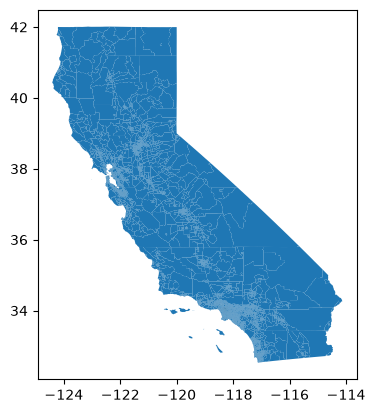

In [13]:
gdf.plot()

In [14]:
gdf['ALAND'].sum() / 1e6

np.float64(403676.564152)

That's just a couple tens of km$^2$ different from the 2019 block-group shapefile in `vmt_explore`.

This time let's quickly preview the whole state using `plot` before subsetting to SF.

### Merge

In [15]:
len(gdf)

9109

In [16]:
len(ca_risk)

9116

That is a small difference of 5 tracts which are likely some sort of outliers.

In [17]:
ca_merged = gdf.merge(ca_risk, left_on='GEOID', right_index=True, how='inner')
len(ca_merged)

9107

And we lost 2 more where the risk is not valid. That's OK. We'd worry if we were losing hundreds or thousands
which would likely indicate a mis-matched census year or another problem.

In [18]:
ca_merged.head()

,STATEFP,COUNTYFP,TRACTCE,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry,rps_2011_mean,rps_2047_mean,building_count
0,06,001,433500,1400000US06001433500,06001433500,4335,Census Tract 4335,CA,Alameda County,California,CT,1234041,0,"POLYGON ((-122.16286 37.69092, -122.16243 37.6...",2.501321e-05,3.190005e-05,1776
1,06,029,003135,1400000US06029003135,06029003135,31.35,Census Tract 31.35,CA,Kern County,California,CT,1385084,0,"POLYGON ((-119.1281 35.30346, -119.12806 35.31...",5.320711e-05,6.363237e-05,1082
2,06,037,920046,1400000US06037920046,06037920046,9200.46,Census Tract 9200.46,CA,Los Angeles County,California,CT,425305,0,"POLYGON ((-118.45585 34.41648, -118.45044 34.4...",7.716418e-05,2.652258e-04,221
3,06,113,010611,1400000US06113010611,06113010611,106.11,Census Tract 106.11,CA,Yolo County,California,CT,481697,0,"POLYGON ((-121.73514 38.56057, -121.73097 38.5...",3.157725e-07,6.324819e-07,543
4,06,037,237300,1400000US06037237300,06037237300,2373,Census Tract 2373,CA,Los Angeles County,California,CT,997691,0,"POLYGON ((-118.31773 33.9782, -118.3177 33.981...",0.000000e+00,0.000000e+00,2929


### Map

<Axes: >

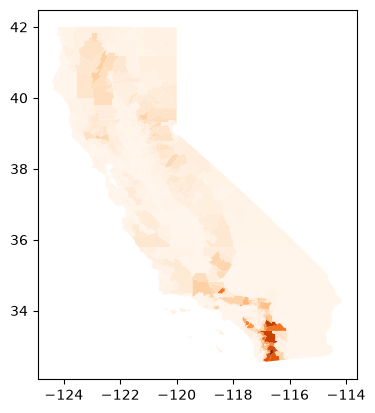

In [19]:
ca_merged.plot(column='rps_2047_mean', cmap='Oranges') # Choose a "sequential" colormap so low values are light

Yup that looks right-- and scary!

OK now we will subset to SF and drop unneeded columns.

In [20]:
SF_FIPS = '075'

sf_merged = ca_merged[ca_merged['COUNTYFP'] == SF_FIPS]
sf_merged = sf_merged.set_index('GEOID')[['rps_2011_mean', 'rps_2047_mean', 'building_count', 'ALAND', 'geometry']]
sf_merged.head()

,rps_2011_mean,rps_2047_mean,building_count,ALAND,geometry
GEOID,,,,,
06075017101,6.914781e-08,3.330987e-08,830,313368,"POLYGON ((-122.44943 37.7632, -122.44827 37.76..."
06075061505,0.000000e+00,0.000000e+00,6,21283,"POLYGON ((-122.39097 37.79007, -122.38943 37.7..."
06075012601,0.000000e+00,0.000000e+00,417,170458,"POLYGON ((-122.4419 37.80374, -122.43714 37.80..."
06075061502,0.000000e+00,0.000000e+00,173,215314,"POLYGON ((-122.39739 37.78255, -122.39516 37.7..."
06075013402,0.000000e+00,0.000000e+00,400,176296,"POLYGON ((-122.44612 37.791, -122.44116 37.791..."


In [21]:
sf_merged[['building_count', 'ALAND']].sum() / 1e6

building_count      0.163491
ALAND             120.913550
dtype: float64

163,000 modeled buildings in SF -- it must drop buildings of some types or in low-risk areas. Good to keep in mind.

In [22]:
sf_merged.explore(column='rps_2047_mean', tiles='CartoDB positron', cmap='Oranges')

SF is pretty safe and boring here. But you can see some very slight, non-zero risk in tracts nearer to parks,
primarily the southern-most tracts abutting San Bruno Mountain.

Remember, following the model documentation, it is conservative in urban areas as it does not explicitly model
urban firestorm dynamics such as experienced by Altadena. So unfortunately these estimates may be considered a
lower bound here. Nevertheless, it is indisputable that SF is at much lower risk that many parts of the state--
another reason to build more housing here!

## Step 3: Merge with ACS owner-occupied housing and median home value data.
### Import using API key wrapper function
This time, unlike in `vmt_explore`, we'll try using the census API. I've adapted a helper function
from [Quinn's example](https://github.com/usf-esm/census_heating_fuel_demo) in a module which we can import.

**First: make sure that you have set up your census API key and copy or link into this directory.**

Creating your API key:
1. Sign up for a free key here: https://api.census.gov/data/key_signup.html.
2. Click the activate button in the email.
3. Copy your key and save it in a one-line python file called "census_api_key.py" that looks like the below, replacing \[YOUR_KEY_HERE\]. Save the file in this directory (or copy or link it in), where it should not be tracked by git as it will match the ".gitignore" pattern.

_census_api_key.py:_

`CENSUS_API_KEY = "[YOUR_KEY_HERE]"`


In [23]:
variables = {'B25077_001E': 'Median owner-occupied home value ($)',
             'B25003_002E': 'Owner-occupied homes'}
# You just have to search for these -- they will come up quickly on a general Google search or 

acs_data = census_helper.retrieve_acs_var(variables, geo='tract')

Status code: 200
[['NAME', 'GEO_ID', 'B25077_001E', 'B25003_002E', 'state', 'county', 'tract'], ['Census Tract 4001; Alameda County; California', '1400000US06001400100', '1790500', '1256', '06', '001', '400100'], ['Census Tract 4002; Alameda County; California', '1400000US06001400200', '1927600', '537', '06', '001', '400200']]
Retrieved ACS variable B25077_001E: renaming as Median owner-occupied home value ($).
Retrieved ACS variable B25003_002E: renaming as Owner-occupied homes.
                                                      NAME  \
GEOID                                                        
06001400100  Census Tract 4001; Alameda County; California   
06001400200  Census Tract 4002; Alameda County; California   
06001400300  Census Tract 4003; Alameda County; California   
06001400400  Census Tract 4004; Alameda County; California   
06001400500  Census Tract 4005; Alameda County; California   

             Median owner-occupied home value ($)  Owner-occupied homes state  \

In [24]:
acs_data.head()

,NAME,Median owner-occupied home value ($),Owner-occupied homes,state,county,tract
GEOID,,,,,,
06001400100,Census Tract 4001; Alameda County; California,1790500,1256,06,001,400100
06001400200,Census Tract 4002; Alameda County; California,1927600,537,06,001,400200
06001400300,Census Tract 4003; Alameda County; California,1751200,1245,06,001,400300
06001400400,Census Tract 4004; Alameda County; California,1586700,910,06,001,400400
06001400500,Census Tract 4005; Alameda County; California,1404600,816,06,001,400500


In [25]:
acs_data['Owner-occupied homes'].sum() / 1e6

np.float64(7.567568)

That worked. 7.6M owner-occupied homes in CA sounds right (a bit more than half of all homes).
And, once we installed our census API key and created the accompanying `census_helper` module,
it was a lot faster than downloading one by one from the website and cleaning!

Let's double check the distribution of the ACS variables returned.

In [26]:
acs_data[['Median owner-occupied home value ($)', 'Owner-occupied homes']].describe()

,Median owner-occupied home value ($),Owner-occupied homes
count,9.129000e+03,9129.000000
mean,-2.498577e+07,828.959141
std,1.287017e+08,507.563001
min,-6.666667e+08,0.000000
25%,4.783000e+05,454.000000
50%,6.955000e+05,772.000000
75%,9.969000e+05,1127.000000
max,2.000001e+06,3993.000000


That's good we did that! It looks like ACS is using a negative home value as a missing data flag.
Let's drop rows where owner-occupied homes is <1 or home value <0.

It also looks like ACS is capping the median home value at $2M. That will also contribute to some
underestimation of total financial exposure.

In [27]:
acs_data_subset = acs_data[(acs_data['Median owner-occupied home value ($)'] >= 0) & (acs_data['Owner-occupied homes'] >= 1)]
# Subset to where both these conditions are true.

acs_data_subset[['Median owner-occupied home value ($)', 'Owner-occupied homes']].describe()

,Median owner-occupied home value ($),Owner-occupied homes
count,8.776000e+03,8776.000000
mean,8.247796e+05,858.921376
std,4.436173e+05,493.361939
min,4.000000e+04,10.000000
25%,5.092000e+05,492.000000
50%,7.140000e+05,794.000000
75%,1.021150e+06,1144.000000
max,2.000001e+06,3993.000000


We lost a few hundred tracts which have only rental housing or too few owner-occupied homes to provide a valid sample for median home-value. That's OK for now.
If we were asking questions specific to rental housing below, we would want to keep these tracts and assign a safe
value for missing data. For example, we could zero out the number owner-occupied homes where there is an invalid median home value and use only weighted averages and other statistics weighted by the the number of homes. Or we could
set negative median home values to zero and use only median and other statistics not especially sensitive to outliers.

### Merge

In [28]:
len(acs_data_subset)

8776

In [29]:
len(sf_merged)

242

In [30]:
new_cols = list(variables.values())
new_cols

['Median owner-occupied home value ($)', 'Owner-occupied homes']

In [31]:
sf_merged_acs = sf_merged.merge(acs_data_subset[new_cols], left_index=True, right_index=True, how='inner')
# Merge in just the new columns.
sf_merged_acs.head()

,rps_2011_mean,rps_2047_mean,building_count,ALAND,geometry,Median owner-occupied home value ($),Owner-occupied homes
GEOID,,,,,,,
06075017101,6.914781e-08,3.330987e-08,830,313368,"POLYGON ((-122.44943 37.7632, -122.44827 37.76...",2000001,552
06075061505,0.000000e+00,0.000000e+00,6,21283,"POLYGON ((-122.39097 37.79007, -122.38943 37.7...",1381300,299
06075012601,0.000000e+00,0.000000e+00,417,170458,"POLYGON ((-122.4419 37.80374, -122.43714 37.80...",2000001,286
06075061502,0.000000e+00,0.000000e+00,173,215314,"POLYGON ((-122.39739 37.78255, -122.39516 37.7...",1554100,346
06075013402,0.000000e+00,0.000000e+00,400,176296,"POLYGON ((-122.44612 37.791, -122.44116 37.791...",2000001,275


In [32]:
len(sf_merged_acs)

217

Let's confirm that the 25 tracts we lost are ones we dropped above for invalid home-value data.

In [33]:
dropped_geoids = set(sf_merged.index).difference(set(sf_merged_acs.index))
# This is good practice to retrieve the indices which were dropped for examination. We convert the
# indices to sets and apply the "difference" function. Remember that the difference is asymmetric,
# it's only showing us GEOIDs which were in the first dataframe but not the second.

dropped_rows = acs_data.loc[list(dropped_geoids)] # Convert the set back to a list to use as an index.
dropped_rows

,NAME,Median owner-occupied home value ($),Owner-occupied homes,state,county,tract
GEOID,,,,,,
06075016200,Census Tract 162; San Francisco County; Califo...,-666666666,344,06,075,016200
06075980401,Census Tract 9804.01; San Francisco County; Ca...,-666666666,0,06,075,980401
06075060100,Census Tract 601; San Francisco County; Califo...,-666666666,9,06,075,060100
06075980200,Census Tract 9802; San Francisco County; Calif...,-666666666,0,06,075,980200
06075012302,Census Tract 123.02; San Francisco County; Cal...,-666666666,0,06,075,012302
06075012503,Census Tract 125.03; San Francisco County; Cal...,-666666666,45,06,075,012503
06075016102,Census Tract 161.02; San Francisco County; Cal...,-666666666,43,06,075,016102
06075061507,Census Tract 615.07; San Francisco County; Cal...,-666666666,213,06,075,061507
06075012404,Census Tract 124.04; San Francisco County; Cal...,-666666666,17,06,075,012404


Yes these all have invalid median home values.

Let's see how many total owner-occupied homes we have left in our dataset.

In [34]:
sf_merged_acs['Owner-occupied homes'].sum()

np.int64(137811)

In [35]:
dropped_rows['Owner-occupied homes'].sum()

np.int64(1246)

OK so we've only lost a bit more than a thousand of 140,000 owner-occupied homes.

## Step 4: Descriptive stats
We'll keep these short; you have more examples in `vmt_explore`, and the rest will be an opportunity for
homework!

### Weighted-average risk
First let's find the average risk for an owner-occupied home in SF in 2011 vs. 2047.

In [36]:
sf_occupied_mean_risk = sf_merged_acs[['rps_2011_mean', 'rps_2047_mean']].apply(lambda x: x * sf_merged_acs['Owner-occupied homes']).sum() / sf_merged_acs['Owner-occupied homes'].sum()
# We have to use an apply because we have different shapes-- multiplying two columns each by one column.
sf_occupied_mean_risk * 1e5 # Show as per 100,000

rps_2011_mean    0.115139
rps_2047_mean    0.108699
dtype: float64

Surprisingly, SF's already very low risk goes down slightly in future climate. That's worth exploring further--
it could be because of increased rainfall etc., but it could also be a model artifact since these values are
already so low.

To remember what this means physically over the lifetime of a mortgage, let's compound this by 30 years.

In [37]:
# Let's make a quick compound risk function: i.e. you can only lose the current structure once.
def compound_risk(x, n=30):
    return (1 - (1 - x) ** n )
    # Each year you have a 1 - x chance of survival. The chance you're still standing over n years is (1-x)^n.
    # Remember that x here must be a fraction, not a percent.

In [38]:
compound_risk(sf_occupied_mean_risk['rps_2047_mean'])

np.float64(3.260913675007249e-05)

Again, the mean risk for owner-occupied housing is negligible in these data: over 30 years the risk is 3 in 100,000.
What about in the worst tract?

In [39]:
worst_risk = sf_merged_acs['rps_2047_mean'].max()
worst_risk

np.float64(4.9452580446401996e-05)

In [40]:
compound_risk(worst_risk)

np.float64(0.0014825140866365771)

Up to 1.5 in 1000 chance over the lifetime of a mortgage. Still financially negligible.
Just for comparison, what about statewide?

In [41]:
worst_risk_ca = ca_merged['rps_2047_mean'].max()
worst_risk_ca

np.float64(0.061416140292617376)

In [42]:
compound_risk(worst_risk_ca)

np.float64(0.8506543942350182)

Yikes! 85% chance of loss over 30 years (around the 2050 climate) for an unimproved home.
No one would insure that: the total insurance premiums would likely exceed the replacement cost of the home.

### Minimum required insurance premium
Let's take that highest-risk neighborhood in SF and estimate the ballpark minimum required insurance premium for the median-priced home: the minimum needed for the insurance company to break even, assuming zero profit or administration costs and assuming that replacement
cost = home value (which is an overestimate).

First we need to find the tract corresponding to that numerically highest risk above. We can use `idxmax`, which finds the index corresponding to the max value.

In [43]:
index = sf_merged_acs['rps_2047_mean'].idxmax()
sf_merged_acs.loc[index]

rps_2011_mean                                                                     0.00005
rps_2047_mean                                                                    0.000049
building_count                                                                       1104
ALAND                                                                              419666
geometry                                POLYGON ((-122.452665 37.708806, -122.449309 3...
Median owner-occupied home value ($)                                              1159300
Owner-occupied homes                                                                 1029
Name: 06075026303, dtype: object

In [44]:
sf_merged_acs.loc[index]['rps_2047_mean'] * sf_merged_acs.loc[index]['Median owner-occupied home value ($)']

np.float64(57.33037651151383)

That's $57 per year needed additional insurance premium (over other insurance costs).

### Total financial exposure
Mirroring the illustration in the forthcoming Buddhavarapu and Subin article, let's sum the total financial liability for SF expected over 30 years in current climate.

We are only considering owner-occupied homes, and we are simplifying by using the median home value in each tract.
This is both an over- and under-estimate: under-estimate because we're using median rather than mean (which ACS does
not report), and over-estimate because the home value includes the land value but we really only want the structure value.

This won't be a problem in SF, but in rural areas with large tracts, we would introduce unknown bias doing this
calculation at the tract level rather than by parcel, because there may be correlations between home value
and risk.

In [45]:
sf_merged_acs['compound_risk2047'] = sf_merged_acs['rps_2047_mean'].map(compound_risk)

total_exposure = (sf_merged_acs['compound_risk2047'] * sf_merged_acs['Median owner-occupied home value ($)'] *
                  sf_merged_acs['Owner-occupied homes']).sum()
total_exposure / 1e6 #M

np.float64(5.103054442026312)

That's $5M. So as far as wildfires go, within the limitations of the model used by Open Climate Risk,
it should be very very cheap to insure SF homes. Dividing by 30 years to annualize and by the number of homes
puts it in the single-digit dollars per yr.

### pivot tables and groupby
So far we haven't introduced one of the most powerful capabilities of pandas, groupby and pivot_tables.
The latter are like you may have used in Excel but allow scalability, replicability, and customization.
For example we can apply a function as the aggregation method.

Let's see if the mean \[unweighted\] neighborhood risk is greater or lesser for neighborhoods with expensive homes.
(Without weighting by tract size, it would be more appropiate to use the median, but in SF the median is zero.) We'll define a function to create a new category column and then use mean as the "aggfunc" (aggregation function).

In [46]:
def expensive_home(home_val, threshold=1.5e6): # Default threshold of $1.5M
    if home_val >= threshold:
        return 'Expensive' # Very expensive actually, these are SF prices!
    else:
        return 'Not as expensive'

sf_merged_acs['expense_category'] = sf_merged_acs['Median owner-occupied home value ($)'].map(expensive_home)
sf_merged_acs.head()

,rps_2011_mean,rps_2047_mean,building_count,ALAND,geometry,Median owner-occupied home value ($),Owner-occupied homes,compound_risk2047,expense_category
GEOID,,,,,,,,,
06075017101,6.914781e-08,3.330987e-08,830,313368,"POLYGON ((-122.44943 37.7632, -122.44827 37.76...",2000001,552,9.992956e-07,Expensive
06075061505,0.000000e+00,0.000000e+00,6,21283,"POLYGON ((-122.39097 37.79007, -122.38943 37.7...",1381300,299,0.000000e+00,Not as expensive
06075012601,0.000000e+00,0.000000e+00,417,170458,"POLYGON ((-122.4419 37.80374, -122.43714 37.80...",2000001,286,0.000000e+00,Expensive
06075061502,0.000000e+00,0.000000e+00,173,215314,"POLYGON ((-122.39739 37.78255, -122.39516 37.7...",1554100,346,0.000000e+00,Expensive
06075013402,0.000000e+00,0.000000e+00,400,176296,"POLYGON ((-122.44612 37.791, -122.44116 37.791...",2000001,275,0.000000e+00,Expensive


In [47]:
sf_merged_acs['compound_risk2011'] = sf_merged_acs['rps_2011_mean'].map(compound_risk) # Add a corresonding 2011 col.

In [48]:
sf_merged_acs.pivot_table(index='expense_category', values=['compound_risk2011', 'compound_risk2047'], aggfunc='mean') * 1e5 # Show per 100,000
# You have as many indices, columns, or values as you want, if you provide lists of column names instead of column names.
# If you have more than one index or column it creates a hierarchical index ("Multi-Index").

,compound_risk2011,compound_risk2047
expense_category,,
Expensive,0.158632,0.155417
Not as expensive,6.084700,5.542682


So the most expensive homes are disproportionately at lower risk-- at least in SF.

That makes sense as the southern Excelsior neighborhoods at highest risk are more middle-income, by SF standards.